In [12]:
import pyvista as pv
import numpy as np

# Load the two VTI files
parallel_data = pv.read('output_3837 domain.vti')
domain_data = pv.read('output_3837 parallel.vti')

# Extract u, v, and pressure from both datasets
dims = parallel_data.dimensions
u_parallel = np.array(parallel_data.point_data["velocity"][:, 0])
v_parallel = np.array(parallel_data.point_data["velocity"][:, 1])
p_parallel = np.array(parallel_data.point_data["pressure"])
u_parallel = u_parallel.reshape(dims)[1:-1, 1:-1]
v_parallel = v_parallel.reshape(dims)[1:-1, 1:-1]
p_parallel = p_parallel.reshape(dims)[1:-1, 1:-1]


dims = domain_data.dimensions
u_domain = np.array(domain_data.point_data["velocity"][:, 0])
v_domain = np.array(domain_data.point_data["velocity"][:, 1])
p_domain = np.array(domain_data.point_data["pressure"])
u_domain = u_domain.reshape(dims)[1:-1, 1:-1]
v_domain = v_domain.reshape(dims)[1:-1, 1:-1]
p_domain = p_domain.reshape(dims)[1:-1, 1:-1]
print(f"argmax indexes p_parallel: {np.argmax(p_domain)}")
print(f"max p_parallel: {np.max(p_domain)}")

# Calculate errors (L2 norm)
error_u = np.linalg.norm(u_parallel - u_domain) / np.linalg.norm(u_domain)
error_v = np.linalg.norm(v_parallel - v_domain) / np.linalg.norm(v_domain)
error_p = np.linalg.norm(p_parallel - p_domain) / np.linalg.norm(p_domain)

print(f"Relative error in u: {error_u:.6e}")
print(f"Relative error in v: {error_v:.6e}")
print(f"Relative error in pressure: {error_p:.6e}")

# Calculate maximum absolute errors
max_error_u = np.max(np.abs(u_parallel - u_domain))
max_error_v = np.max(np.abs(v_parallel - v_domain))
max_error_p = np.max(np.abs(p_parallel - p_domain))

print(f"\nMaximum absolute error in u: {max_error_u:.6e}")
print(f"Maximum absolute error in v: {max_error_v:.6e}")
print(f"Maximum absolute error in pressure: {max_error_p:.6e}")


argmax indexes p_parallel: 360
max p_parallel: 0.08164096546351281
Relative error in u: 8.583552e-06
Relative error in v: 6.644217e-06
Relative error in pressure: 2.514570e-02

Maximum absolute error in u: 1.915679e-06
Maximum absolute error in v: 1.840223e-06
Maximum absolute error in pressure: 3.879920e-03


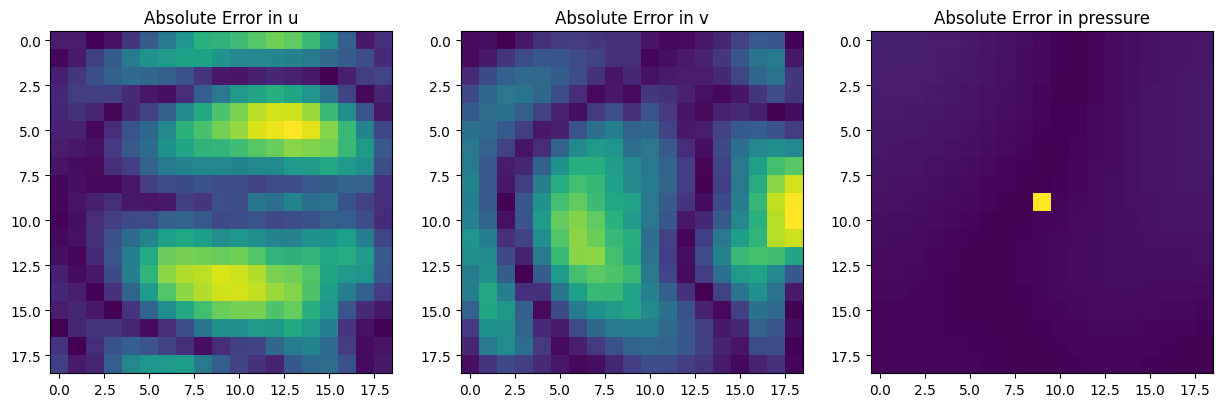

In [7]:
# Visualize the differences using matplotlib
import matplotlib.pyplot as plt
u_diff_abs = np.abs(u_parallel - u_domain)
v_diff_abs = np.abs(v_parallel - v_domain)
p_diff_abs = np.abs(p_parallel - p_domain)
fig, axs = plt.subplots(1, 3, figsize=(15, 12))
axs = axs.flatten()
axs[0].imshow(u_diff_abs)
axs[0].set_title('Absolute Error in u')
axs[1].imshow(v_diff_abs)
axs[1].set_title('Absolute Error in v')
axs[2].imshow(p_diff_abs)
axs[2].set_title('Absolute Error in pressure')
plt.show()